# Assignment - PY/01

## Assignment Details
- Create a notebook that uses the **airquality** dataset from `pydataset` and walks students through core pandas skills: structure, head/tail, summary stats, missing values, selection, filtering, sorting, duplicates, derived columns, and groupby/aggregation.

## Practise Exercises

- Inspecting structure: shape, dtypes, info, head, tail
- Summary stats: describe, nunique
- Missing values: isna, fillna (median/mean imputation)
- Selecting columns/rows: lists, iloc, boolean masks, isin
- Filtering with conditions and ranges
- Sorting by multiple columns
- Duplicates: duplicated, drop_duplicates
- Derived columns & categorization: arithmetic, pd.cut
- Groupby & aggregation: agg, boolean-to-int counting
- (Optional) quick sanity plots

## Few Initial Commands to help you load the data

In [1]:
# Install libraries if not available
import pandas as pd
import numpy as np
from pydataset import data

In [2]:
# Option A: Load directly from pydataset
df = data('airquality')

In [3]:
df.shape

(153, 6)

In [4]:
df.head(2)

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2


## Tasks

### Task 1. Inspect the structure

- Show the shape (rows, columns)
- List column names and dtypes
- Display the first 5 and last 5 rows

> **Hints:** `df.shape`, `df.dtypes`, `df.columns`, `df.head()`, `df.tail()`, `df.info()`

In [5]:
# Shape
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (153, 6)


In [6]:
# Column names & dtypes
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)

Columns: ['Ozone', 'Solar.R', 'Wind', 'Temp', 'Month', 'Day']

Ozone      float64
Solar.R    float64
Wind       float64
Temp         int64
Month        int64
Day          int64
dtype: object


In [7]:
# Head and Tails
display(df.head(5))
display(df.tail(5))

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


,Ozone,Solar.R,Wind,Temp,Month,Day
149,30.0,193.0,6.9,70,9,26
150,NaN,145.0,13.2,77,9,27
151,14.0,191.0,14.3,75,9,28
152,18.0,131.0,8.0,76,9,29
153,20.0,223.0,11.5,68,9,30


In [8]:
# Info Summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


### Task 2. Basic summary stats

- Produce descriptive statistics for numeric columns.
- For each column, show number of unique values.

> **Hints:** `df.describe()`, `df.nunique()`

In [9]:
# code for Task 2
display(df.describe())
print()
print("Unique values per column:")
print(df.nunique())

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000



Unique values per column:
Ozone       67
Solar.R    117
Wind        31
Temp        40
Month        5
Day         31
dtype: int64


### Task 3. Missing values

- Count missing values per column.
- Create a copy `df_mv` where you impute:
    - `Ozone`: fill with the column median (numeric)
    - `Solar.R`: fill with the column mean (numeric)
- Briefly comment: why might median be preferred over mean in some cases? (Add a markdown cell.)

> **Hints:** `df.isna().sum()`, `df.copy()`, `fillna()`

In [10]:
# code for Task 3
print("Missing values per column:")
print(df.isna().sum())

df_mv = df.copy()
df_mv['Ozone'] = df_mv['Ozone'].fillna(df_mv['Ozone'].median())
df_mv['Solar.R'] = df_mv['Solar.R'].fillna(df_mv['Solar.R'].mean())

print()
print("Missing values after imputation:")
print(df_mv.isna().sum())

Missing values per column:
Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

Missing values after imputation:
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


**Why median over mean?** The median is more robust to outliers and skewed distributions — a few unusually high (or low) readings can pull the mean far from where most of the data actually sits, while the median stays anchored to the middle of the data. For a variable like `Ozone`, which tends to be right-skewed with occasional spikes, the median gives a more representative "typical" value than the mean does.

### Task 4. Selecting columns & rows

- Select the columns: `Ozone`, `Solar.R`, `Temp` into a new DataFrame `df_sel`.
- Select the first **10 rows** of `df_sel`.
- Select rows where `Month` is **May (5)** or **June (6)** only.

> **Hints:** Column lists, `iloc`, boolean masks, `isin`

In [11]:
# code for Task 4
df_sel = df[['Ozone', 'Solar.R', 'Temp']]
display(df_sel.head())

first_10 = df_sel.iloc[:10]
display(first_10)

may_june = df[df['Month'].isin([5, 6])]
display(may_june.head())
print("Rows in May/June:", may_june.shape[0])

,Ozone,Solar.R,Temp
1,41.0,190.0,67
2,36.0,118.0,72
3,12.0,149.0,74
4,18.0,313.0,62
5,NaN,NaN,56


,Ozone,Solar.R,Temp
1,41.0,190.0,67
2,36.0,118.0,72
3,12.0,149.0,74
4,18.0,313.0,62
5,NaN,NaN,56
6,28.0,NaN,66
7,23.0,299.0,65
8,19.0,99.0,59
9,8.0,19.0,61
10,NaN,194.0,69


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


Rows in May/June: 61


### Task 5. Filtering & conditions

- Filter rows where `Ozone` > 100 **and** `Temp` >= 85.
- Filter rows where `Solar.R` is missing.
- Filter rows for **July (7)** with `Ozone` between **50 and 100** (inclusive).

> **Hints:** Combined boolean conditions with `&`, `|`, parentheses; `between()`

In [12]:
# code for Task 5
high_ozone_hot = df[(df['Ozone'] > 100) & (df['Temp'] >= 85)]
display(high_ozone_hot)

missing_solar = df[df['Solar.R'].isna()]
display(missing_solar)

july_ozone_range = df[(df['Month'] == 7) & (df['Ozone'].between(50, 100))]
display(july_ozone_range)

,Ozone,Solar.R,Wind,Temp,Month,Day
86,108.0,223.0,8.0,85,7,25
99,122.0,255.0,4.0,89,8,7
101,110.0,207.0,8.0,90,8,9
121,118.0,225.0,2.3,94,8,29


,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
11,7.0,NaN,6.9,74,5,11
27,NaN,NaN,8.0,57,5,27
96,78.0,NaN,6.9,86,8,4
97,35.0,NaN,7.4,85,8,5
98,66.0,NaN,4.6,87,8,6


,Ozone,Solar.R,Wind,Temp,Month,Day
66,64.0,175.0,4.6,83,7,5
68,77.0,276.0,5.1,88,7,7
69,97.0,267.0,6.3,92,7,8
70,97.0,272.0,5.7,92,7,9
71,85.0,175.0,7.4,89,7,10
79,61.0,285.0,6.3,84,7,18
80,79.0,187.0,5.1,87,7,19
81,63.0,220.0,11.5,85,7,20
85,80.0,294.0,8.6,86,7,24
88,52.0,82.0,12.0,86,7,27


### Task 6. Sorting

- Sort the dataset by `Ozone` **descending** and `Temp` **ascending** (multi-column sort).
- Sort the dataset by `Month` then `Day` to get chronological order.

> **Hints:** `sort_values(by=[...], ascending=[...])`

In [13]:
# code for Task 6
sorted_ozone_temp = df.sort_values(by=['Ozone', 'Temp'], ascending=[False, True])
display(sorted_ozone_temp.head(10))

sorted_chrono = df.sort_values(by=['Month', 'Day'])
display(sorted_chrono.head(10))

,Ozone,Solar.R,Wind,Temp,Month,Day
117,168.0,238.0,3.4,81,8,25
62,135.0,269.0,4.1,84,7,1
99,122.0,255.0,4.0,89,8,7
121,118.0,225.0,2.3,94,8,29
30,115.0,223.0,5.7,79,5,30
101,110.0,207.0,8.0,90,8,9
86,108.0,223.0,8.0,85,7,25
69,97.0,267.0,6.3,92,7,8
70,97.0,272.0,5.7,92,7,9
124,96.0,167.0,6.9,91,9,1


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
7,23.0,299.0,8.6,65,5,7
8,19.0,99.0,13.8,59,5,8
9,8.0,19.0,20.1,61,5,9
10,NaN,194.0,8.6,69,5,10


### Task 7 Duplicates

- Check if there are any fully duplicated rows.
- Intentionally create a few duplicate rows (e.g., duplicate first 3 rows) into `df_dup`.
- Remove duplicates and report how many were removed.

> **Hints:** `df.duplicated()`, `pd.concat([...])`, `drop_duplicates()`

In [14]:
# code for Task 7
print("Any fully duplicated rows originally?", df.duplicated().any())

df_dup = pd.concat([df, df.head(3)], ignore_index=True)
print("Shape with intentional duplicates:", df_dup.shape)
print("Number of duplicated rows:", df_dup.duplicated().sum())

df_clean = df_dup.drop_duplicates()
removed = df_dup.shape[0] - df_clean.shape[0]
print(f"Rows removed: {removed}")
print("Shape after removing duplicates:", df_clean.shape)

Any fully duplicated rows originally? False
Shape with intentional duplicates: (156, 6)
Number of duplicated rows: 3
Rows removed: 3
Shape after removing duplicates: (153, 6)


### Task 8. Derived columns

- Create a new column `Temp_C` converting Fahrenheit to Celsius.
- Flag a new boolean column `High_Ozone` where `Ozone` > 100.
- Create a categorical column `Temp_Band` with labels: `Cool (<75F)`, `Warm (75-85F)`, `Hot (>85F)`.

> **Hints:** vectorized arithmetic, `pd.cut()`

In [15]:
# code for Task 8
df['Temp_C'] = (df['Temp'] - 32) * 5 / 9
df['High_Ozone'] = df['Ozone'] > 100

df['Temp_Band'] = pd.cut(
    df['Temp'],
    bins=[-float('inf'), 74, 85, float('inf')],
    labels=['Cool (<75F)', 'Warm (75-85F)', 'Hot (>85F)']
)

display(df.head(10))
print(df['Temp_Band'].value_counts())

,Ozone,Solar.R,Wind,Temp,Month,Day,Temp_C,High_Ozone,Temp_Band
1,41.0,190.0,7.4,67,5,1,19.444444,False,Cool (<75F)
2,36.0,118.0,8.0,72,5,2,22.222222,False,Cool (<75F)
3,12.0,149.0,12.6,74,5,3,23.333333,False,Cool (<75F)
4,18.0,313.0,11.5,62,5,4,16.666667,False,Cool (<75F)
5,NaN,NaN,14.3,56,5,5,13.333333,False,Cool (<75F)
6,28.0,NaN,14.9,66,5,6,18.888889,False,Cool (<75F)
7,23.0,299.0,8.6,65,5,7,18.333333,False,Cool (<75F)
8,19.0,99.0,13.8,59,5,8,15.000000,False,Cool (<75F)
9,8.0,19.0,20.1,61,5,9,16.111111,False,Cool (<75F)
10,NaN,194.0,8.6,69,5,10,20.555556,False,Cool (<75F)


Temp_Band
Warm (75-85F)    71
Cool (<75F)      48
Hot (>85F)       34
Name: count, dtype: int64


### Task 9. Groupby & aggregation

- Group by `Month` and compute **mean Ozone**, **median Solar.R**, and **max Temp**.
- Within each `Month`, count how many days have `Ozone` > 80.

> **Hints:** `groupby()`, `agg({...})`, Boolean to int conversion or `np.sum()`

In [16]:
# code for Task 9
monthly_stats = df.groupby('Month').agg(
    mean_Ozone=('Ozone', 'mean'),
    median_Solar_R=('Solar.R', 'median'),
    max_Temp=('Temp', 'max')
)
display(monthly_stats)

df['Ozone_gt_80'] = (df['Ozone'] > 80).astype(int)
high_ozone_days = df.groupby('Month')['Ozone_gt_80'].sum()
print("Days with Ozone > 80 per month:")
print(high_ozone_days)

,mean_Ozone,median_Solar_R,max_Temp
Month,,,
5,23.615385,194.0,81
6,29.444444,188.5,93
7,59.115385,253.0,92
8,59.961538,197.5,97
9,31.448276,192.0,93


Days with Ozone > 80 per month:
Month
5    1
6    0
7    6
8    7
9    2
Name: Ozone_gt_80, dtype: int64


### Task 10.(Stretch) Quick sanity plots *(optional)*
If permitted, create two simple charts to visualize patterns:
- Histogram of `Ozone` (after imputation, using `df_mv` if you created it).
- Line plot of `Temp` across days for **August (8)** ordered by Day.

> **Hints:** `matplotlib` basic plotting

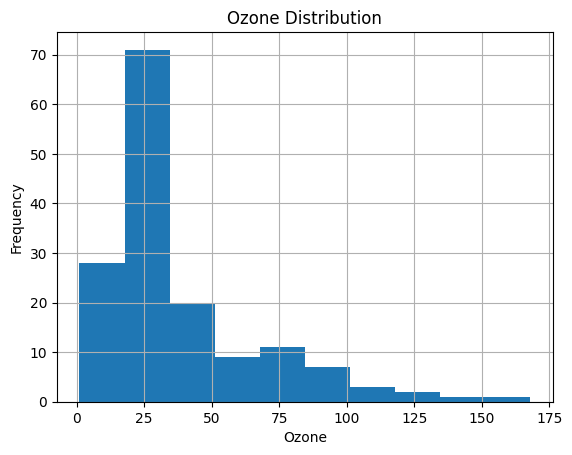

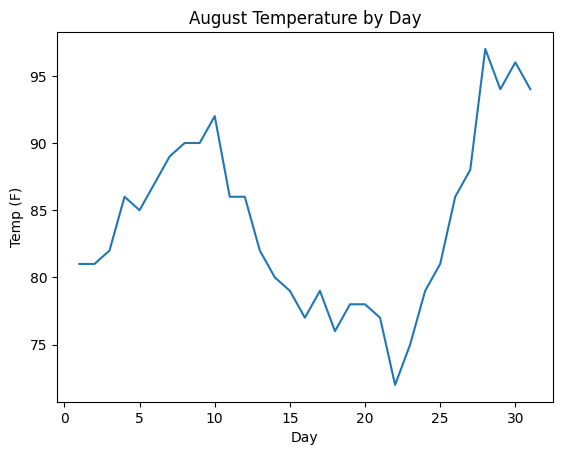

In [17]:
# Your code for Task 10 (optional)
import matplotlib.pyplot as plt

df_mv['Ozone'].hist()
plt.title('Ozone Distribution')
plt.xlabel('Ozone')
plt.ylabel('Frequency')
plt.show()

august = df[df['Month'] == 8].sort_values('Day')
plt.plot(august['Day'], august['Temp'])
plt.title('August Temperature by Day')
plt.xlabel('Day')
plt.ylabel('Temp (F)')
plt.show()

## ✅ Deliverables

- Complete all code cells under each task.
- Add **one short markdown cell** summarizing **two insights** you learned (e.g., months with higher ozone, missingness patterns, hottest months).

### Insights

1. **Ozone levels peak in the summer months.** July and August show the highest mean `Ozone` readings and the most days with `Ozone` > 80, consistent with stronger sunlight and higher temperatures driving ozone formation.
2. **Missingness is concentrated in a few columns.** `Ozone` and `Solar.R` account for almost all the missing values in the dataset, while `Wind`, `Temp`, `Month`, and `Day` are fully complete — suggesting the gaps come from instrument/reporting issues specific to those two measurements rather than random data loss.

## 📝 Evaluation (Suggested)

- **Accuracy & Correctness (40%)** – Tasks solved correctly, edge cases handled.
- **Clarity & Clean Code (20%)** – Clear variable names, comments where helpful.